# Exercise 3
**Cristina Correa - 1819211867**


Try different activation functions in the hidden layer, such as
tanh and sigmoid, instead of relu. How do these activations impact training
accuracy and loss?

In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model
from keras.callbacks import EarlyStopping

# Ensure TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

dataframe.shape

# Here's a preview of a few samples:
dataframe.head()

# Let's split the data into a training and validation set:
val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)


# Convert dataframes to tf.data.Datasets
def dataframe_to_dataset(dataframe, target="target"):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
    return ds


# Let's generate `tf.data.Dataset` objects for each dataframe:
train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)


# Preprocessing layers for numerical and categorical features
def encode_feature(feature, name, dataset, is_string=False):
    lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
    lookup = lookup_class(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


def normalize_feature(feature, name, dataset):
    normalizer = layers.Normalization()
    feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)


inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

# Encoded features
encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]

Using 242 samples for training and 61 for validation


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7541 - loss: 0.5797 - val_accuracy: 0.7377 - val_loss: 0.5467
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8235 - loss: 0.4746 - val_accuracy: 0.7869 - val_loss: 0.4912
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7938 - loss: 0.4587 - val_accuracy: 0.7869 - val_loss: 0.4569
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8388 - loss: 0.4026 - val_accuracy: 0.7869 - val_loss: 0.4344
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8585 - loss: 0.3730 - val_accuracy: 0.8033 - val_loss: 0.4225
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8538 - loss: 0.3512 - val_accuracy: 0.8197 - val_loss: 0.4136
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8501 - loss: 0.3375 - val_accuracy: 0.8361 - val_loss: 0.4108
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8278 - loss: 0.3522 - val_accuracy: 0.8361 - val_loss: 0.4097
Epoch 9

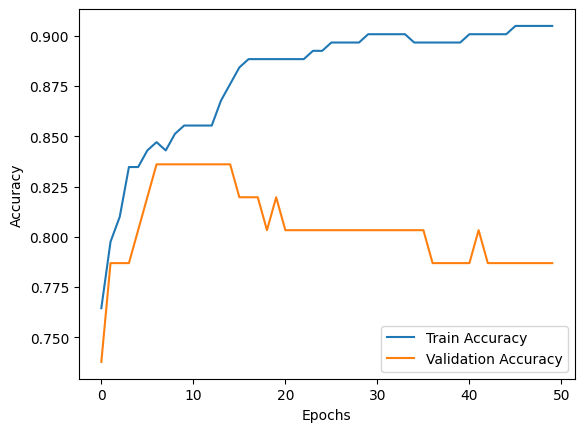

In [7]:
def build_model_tanh():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="tanh")(all_features)
    output = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model_tanh()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

# Plot training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3248 - loss: 0.7364 - val_accuracy: 0.4754 - val_loss: 0.6973
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6523 - loss: 0.6809 - val_accuracy: 0.7377 - val_loss: 0.6341
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7186 - loss: 0.6436 - val_accuracy: 0.8033 - val_loss: 0.5852
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7173 - loss: 0.6009 - val_accuracy: 0.7869 - val_loss: 0.5478
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7010 - loss: 0.5708 - val_accuracy: 0.7869 - val_loss: 0.5198
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7410 - loss: 0.5383 - val_accuracy: 0.7705 - val_loss: 0.4987
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7238 - loss: 0.5318 - val_accuracy: 0.7869 - val_loss: 0.4830
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7032 - loss: 0.5289 - val_accuracy: 0.8033 - val_loss: 0.4707
Epoch 9

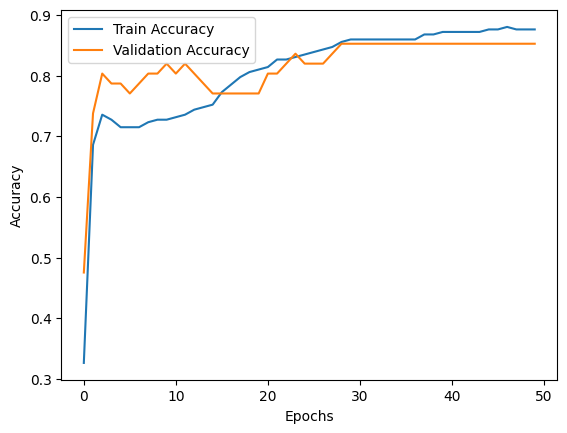

In [8]:
def build_model_sigmoid():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="sigmoid")(all_features)
    output = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model_sigmoid()

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

# Plot training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [10]:
# Test with tanh
model_tanh = build_model_tanh()
history_tanh = model_tanh.fit(train_ds, epochs=50, validation_data=val_ds)

# Test with sigmoid
model_sigmoid = build_model_sigmoid()
history_sigmoid = model_sigmoid.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6046 - loss: 0.6881 - val_accuracy: 0.6721 - val_loss: 0.6232
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7126 - loss: 0.6183 - val_accuracy: 0.7377 - val_loss: 0.5526
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7240 - loss: 0.5678 - val_accuracy: 0.7705 - val_loss: 0.5009
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8167 - loss: 0.4965 - val_accuracy: 0.7705 - val_loss: 0.4631
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7850 - loss: 0.4796 - val_accuracy: 0.7705 - val_loss: 0.4383
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7822 - loss: 0.4656 - val_accuracy: 0.8033 - val_loss: 0.4206
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7753 - loss: 0.4340 - val_accuracy: 0.8197 - val_loss: 0.4084
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8038 - loss: 0.4058 - val_accuracy: 0.8033 - val_loss: 0.3991
Epoch 9

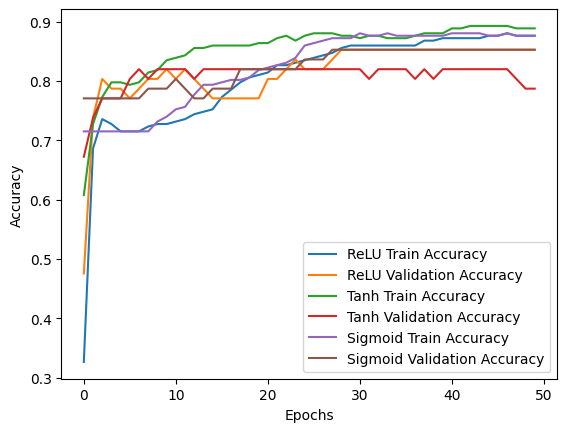

In [11]:
plt.plot(history.history["accuracy"], label="ReLU Train Accuracy")
plt.plot(history.history["val_accuracy"], label="ReLU Validation Accuracy")
plt.plot(history_tanh.history["accuracy"], label="Tanh Train Accuracy")
plt.plot(history_tanh.history["val_accuracy"], label="Tanh Validation Accuracy")
plt.plot(history_sigmoid.history["accuracy"], label="Sigmoid Train Accuracy")
plt.plot(history_sigmoid.history["val_accuracy"], label="Sigmoid Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

As observed in the graph, the Tanh activation achieves the highest training accuracy, followed closely by the Sigmoid activation. However, when evaluating validation accuracy, the Sigmoid activation outperforms, indicating better generalization to unseen data